## Meta Platforms Inc. (FB) Exploratory Data Analysis

### Overview
This notebook presents an exploratory data analysis (EDA) of financial news headlines related to **Meta Platforms Inc. (FB)**. The analysis is part of a broader project at **Nova Financial Solutions** aimed at building a predictive analytics pipeline that connects market narratives to stock price movements.

### Objectives
- Understand the structure and statistical properties of the financial news dataset
- Identify common keywords, themes, and topics in FB-related headlines
- Analyze publication trends and volume spikes over time
- Examine publisher activity and contribution patterns

### Dataset
The analysis uses the **Financial News and Stock Price Integration Dataset (FNSPID)**, which contains financial news headlines, publication dates, publisher information, and associated stock ticker symbols.

## 1. Import Libraries

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import nltk
from nltk.corpus import stopwords
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation
from textblob import TextBlob
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
import re
import warnings
warnings.filterwarnings('ignore')

nltk.download('stopwords')
nltk.download('punkt')
nltk.download('punkt_tab')

plt.style.use('seaborn-v0_8')
sns.set_palette('husl')

print("✅ All libraries imported successfully!")

✅ All libraries imported successfully!


[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\user\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\user\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\user\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


## 2. Loading the Data

We begin by loading the raw financial news dataset. The dataset contains news articles from multiple publishers with their publication dates and associated stock ticker symbols.

In [5]:
df = pd.read_csv('../data/raw/raw_analyst_ratings.csv')

print(f"Dataset Shape: {df.shape}")
print(f"\nColumn Names: {df.columns.tolist()}")
print(f"\nFirst 5 rows:")
df.head()

Dataset Shape: (1407328, 6)

Column Names: ['Unnamed: 0', 'headline', 'url', 'publisher', 'date', 'stock']

First 5 rows:


,Unnamed: 0,headline,url,publisher,date,stock
0,0,Stocks That Hit 52-Week Highs On Friday,https://www.benzinga.com/news/20/06/16190091/s...,Benzinga Insights,2020-06-05 10:30:54-04:00,A
1,1,Stocks That Hit 52-Week Highs On Wednesday,https://www.benzinga.com/news/20/06/16170189/s...,Benzinga Insights,2020-06-03 10:45:20-04:00,A
2,2,71 Biggest Movers From Friday,https://www.benzinga.com/news/20/05/16103463/7...,Lisa Levin,2020-05-26 04:30:07-04:00,A
3,3,46 Stocks Moving In Friday's Mid-Day Session,https://www.benzinga.com/news/20/05/16095921/4...,Lisa Levin,2020-05-22 12:45:06-04:00,A
4,4,B of A Securities Maintains Neutral on Agilent...,https://www.benzinga.com/news/20/05/16095304/b...,Vick Meyer,2020-05-22 11:38:59-04:00,A


## 3. Data Cleaning & Filtering

Before analysis we clean the dataset by:
- Dropping the unnecessary unnamed index column
- Parsing the date column handling mixed timezone formats
- Fixing inconsistent publisher names
- Filtering for **FB** articles only

In [6]:
df = df.drop(columns=['Unnamed: 0'])
df['date'] = pd.to_datetime(df['date'], format='mixed', utc=True)
df['publisher'] = df['publisher'].replace('Benzinga_Newsdesk', 'Benzinga Newsdesk')

fb_df = df[df['stock'] == 'FB'].copy().reset_index(drop=True)

print(f"Total FB articles: {len(fb_df)}")
print(f"\nDate range: {fb_df['date'].min().date()} to {fb_df['date'].max().date()}")
print(f"\nMissing values:\n{fb_df.isnull().sum()}")
fb_df.head()

Total FB articles: 380

Date range: 2020-02-19 to 2020-06-10

Missing values:
headline     0
url          0
publisher    0
date         0
stock        0
dtype: int64


,headline,url,publisher,date,stock
0,As Expected: Fed Keeps Rates Unchanged and For...,https://www.benzinga.com/news/20/06/16226512/a...,JJ Kinahan,2020-06-10 20:20:19+00:00,FB
1,"Facebook, Snap Analyst Projects Q2 Revenue Ups...",https://www.benzinga.com/analyst-ratings/analy...,Shanthi Rexaline,2020-06-10 19:25:13+00:00,FB
2,Tech Stocks And FAANGS Strong Again To Start D...,https://www.benzinga.com/government/20/06/1622...,JJ Kinahan,2020-06-10 15:33:26+00:00,FB
3,Big Tech Reaches New Record Heights At The Sto...,https://www.benzinga.com/news/20/06/16218615/b...,Neer Varshney,2020-06-10 04:52:01+00:00,FB
4,"Twitter, Square Will Mark Juneteenth As Holida...",https://www.benzinga.com/news/20/06/16218441/t...,Shivdeep Dhaliwal,2020-06-10 04:28:00+00:00,FB


## 4. Descriptive Statistics

In this section we examine the basic statistical properties of the dataset including headline length distribution, article count over time, and a general summary of the data.

In [7]:
fb_df['headline_length'] = fb_df['headline'].apply(len)

print("=== Headline Length Statistics ===")
print(fb_df['headline_length'].describe())

print(f"\n=== Sample Headlines ===")
for h in fb_df['headline'].sample(5, random_state=42).values:
    print(f"• {h}")

=== Headline Length Statistics ===
count    380.000000
mean      87.413158
std       46.016406
min       26.000000
25%       61.000000
50%       76.000000
75%       93.250000
max      290.000000
Name: headline_length, dtype: float64

=== Sample Headlines ===
• Morgan Stanley Maintains Overweight on Facebook, Lowers Price Target to $185
• Hearing Some Users Reporting Facebook's WhatsApp, Instagram Down
• Ad Sales Decrease With Covid-19 But Digital Holds The Key
• Trump's Executive Order To Expose Social Media To Lawsuits Over Content Policies
• Zuckerberg Says Facebook Policies Allow For Stronger Free Expression


### 4.1 Headline Length Distribution

We visualize the distribution of headline character lengths to understand how concise or verbose the financial news headlines tend to be.

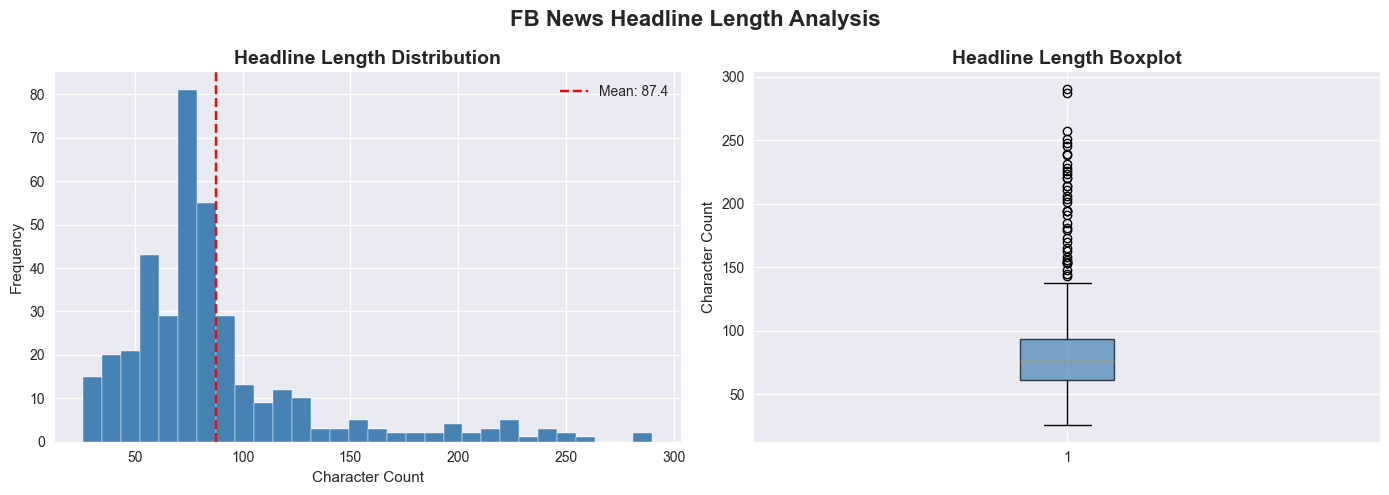

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(fb_df['headline_length'], bins=30, color='steelblue', edgecolor='white')
axes[0].set_title('Headline Length Distribution', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Character Count')
axes[0].set_ylabel('Frequency')
axes[0].axvline(fb_df['headline_length'].mean(), color='red', linestyle='--',
                label=f"Mean: {fb_df['headline_length'].mean():.1f}")
axes[0].legend()

axes[1].boxplot(fb_df['headline_length'], patch_artist=True,
                boxprops=dict(facecolor='steelblue', alpha=0.7))
axes[1].set_title('Headline Length Boxplot', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Character Count')

plt.suptitle('FB News Headline Length Analysis', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

## 5. Publisher Analysis

We identify the most active publishers contributing to FB-related news. Understanding which sources dominate the coverage helps assess potential bias and the diversity of market perspectives.

In [9]:
publisher_counts = fb_df['publisher'].value_counts()

print(f"Total unique publishers: {publisher_counts.nunique()}")
print(f"\nTop 10 most active publishers:")
print(publisher_counts.head(10))

Total unique publishers: 17

Top 10 most active publishers:
publisher
Benzinga Newsdesk    111
Neer Varshney         56
Shivdeep Dhaliwal     29
IAM Newswire          22
JJ Kinahan            21
Vick Meyer            20
Lisa Levin            19
Benzinga Insights     16
Wayne Duggan          12
Jayson Derrick         9
Name: count, dtype: int64


### 5.1 Publisher Activity Visualization

The bar chart below highlights the dominance of certain publishers in FB news coverage, particularly **Benzinga Newsdesk** which accounts for the majority of articles.

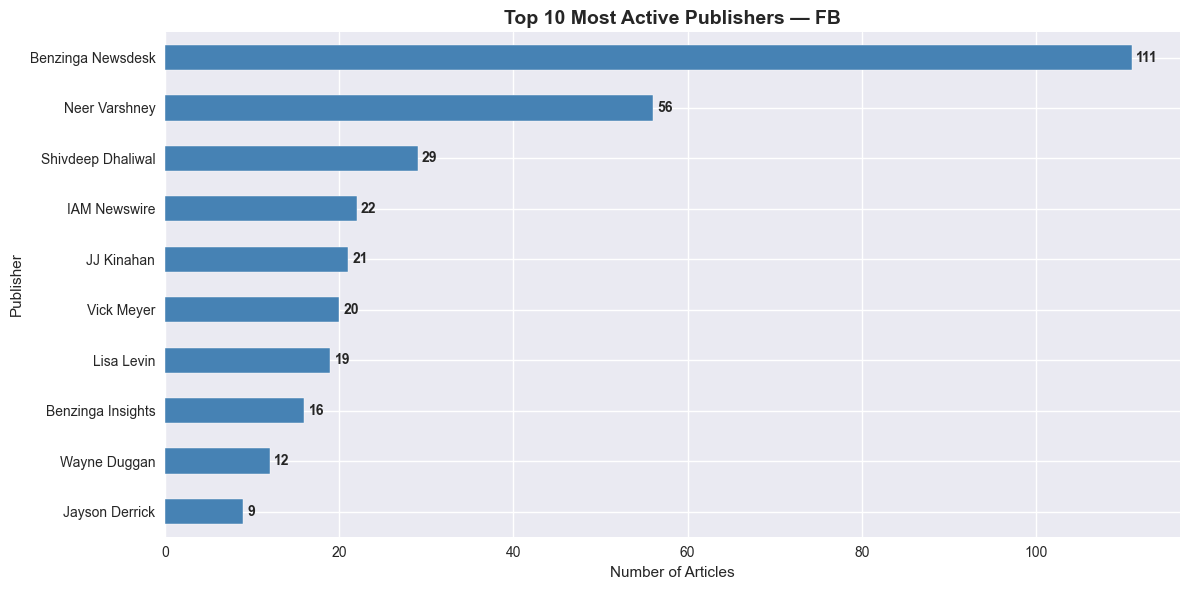

In [10]:
fig, ax = plt.subplots(figsize=(12, 6))

publisher_counts.head(10).plot(kind='barh', ax=ax, color='steelblue', edgecolor='white')

ax.set_title('Top 10 Most Active Publishers — FB', fontsize=14, fontweight='bold')
ax.set_xlabel('Number of Articles')
ax.set_ylabel('Publisher')
ax.invert_yaxis()

for i, v in enumerate(publisher_counts.head(10)):
    ax.text(v + 0.5, i, str(v), va='center', fontweight='bold')

plt.tight_layout()
plt.show()

### 5.2 Email Publisher Domain Analysis

Some publishers use email addresses as their names. We extract the domain from these emails to identify the organizations contributing to the news coverage.

Articles from email-based publishers: 6
Unique email publishers: 2

Top domains:
domain
benzinga.com    6
Name: count, dtype: int64


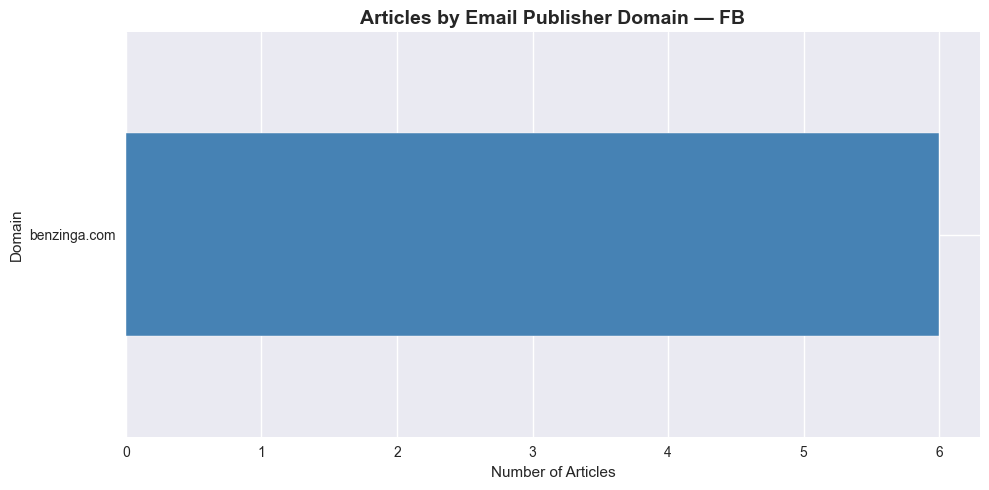

In [11]:
email_publishers = fb_df[fb_df['publisher'].str.contains('@', na=False)]

print(f"Articles from email-based publishers: {len(email_publishers)}")
print(f"Unique email publishers: {email_publishers['publisher'].nunique()}")

if len(email_publishers) > 0:
    email_publishers = email_publishers.copy()
    email_publishers['domain'] = email_publishers['publisher'].str.extract(r'@([\w.]+)')
    domain_counts = email_publishers['domain'].value_counts()
    print(f"\nTop domains:\n{domain_counts}")

    fig, ax = plt.subplots(figsize=(10, 5))
    domain_counts.plot(kind='barh', ax=ax, color='steelblue', edgecolor='white')
    ax.set_title('Articles by Email Publisher Domain — FB',
                 fontsize=14, fontweight='bold')
    ax.set_xlabel('Number of Articles')
    ax.set_ylabel('Domain')
    ax.invert_yaxis()
    plt.tight_layout()
    plt.show()
else:
    print("No email-based publishers found for this stock.")

## 6. Time Series Analysis of News Volume

We analyze how FB-related article publication frequency varies over time. Spikes in news volume often correlate with significant market events such as earnings releases, product launches, or macroeconomic developments.

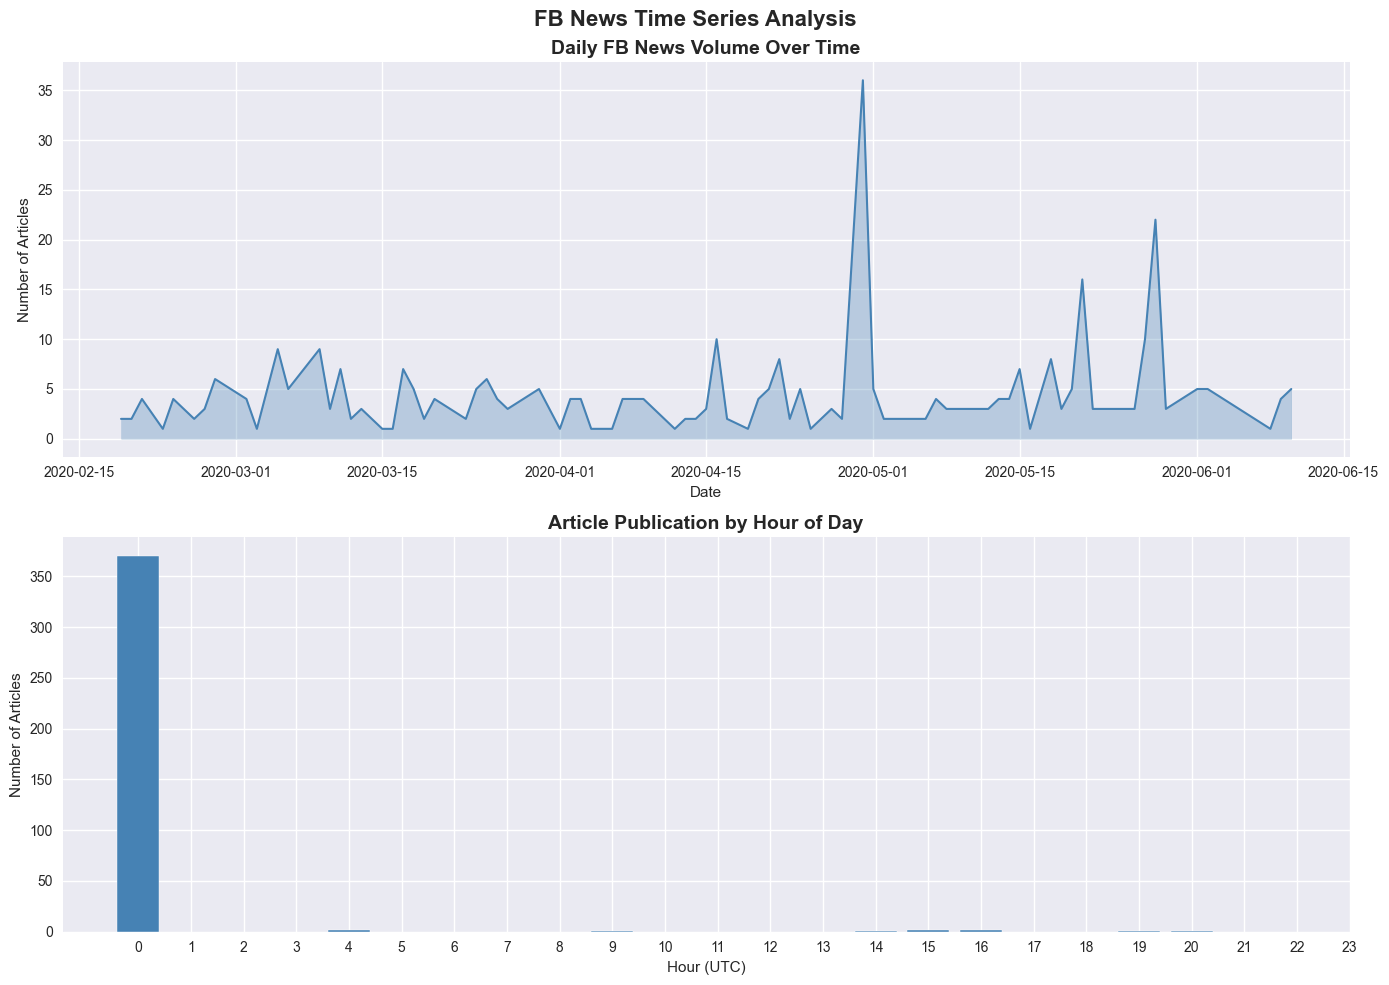

In [12]:
fb_df['date_only'] = fb_df['date'].dt.date
fb_df['hour'] = fb_df['date'].dt.hour
fb_df['day_of_week'] = fb_df['date'].dt.day_name()

daily_counts = fb_df.groupby('date_only').size()

fig, axes = plt.subplots(2, 1, figsize=(14, 10))

axes[0].plot(daily_counts.index, daily_counts.values, color='steelblue', linewidth=1.5)
axes[0].fill_between(daily_counts.index, daily_counts.values, alpha=0.3, color='steelblue')
axes[0].set_title('Daily FB News Volume Over Time', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Date')
axes[0].set_ylabel('Number of Articles')

hour_counts = fb_df['hour'].value_counts().sort_index()
axes[1].bar(hour_counts.index, hour_counts.values, color='steelblue', edgecolor='white')
axes[1].set_title('Article Publication by Hour of Day', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Hour (UTC)')
axes[1].set_ylabel('Number of Articles')
axes[1].set_xticks(range(0, 24))

plt.suptitle('FB News Time Series Analysis', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

## 7. Text Analysis & Topic Modeling

We apply NLP techniques to extract the most frequent keywords and themes from FB-related headlines. This helps identify recurring topics such as earnings, price targets, and product announcements that drive market attention. We use three complementary approaches: **TF-IDF**, **CountVectorizer**, and **LDA Topic Modeling**.

In [13]:
stop_words = set(stopwords.words('english'))

def clean_headline(text):
    text = text.lower()
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    tokens = text.split()
    tokens = [t for t in tokens if t not in stop_words and len(t) > 2]
    return ' '.join(tokens)

fb_df['cleaned_headline'] = fb_df['headline'].apply(clean_headline)

# TF-IDF
tfidf = TfidfVectorizer(max_features=20, ngram_range=(1,2))
tfidf_matrix = tfidf.fit_transform(fb_df['cleaned_headline'])
tfidf_keywords = tfidf.get_feature_names_out()

# CountVectorizer
vectorizer = CountVectorizer(max_features=20, ngram_range=(1,2))
word_matrix = vectorizer.fit_transform(fb_df['cleaned_headline'])
word_freq = pd.DataFrame({
    'keyword': vectorizer.get_feature_names_out(),
    'frequency': word_matrix.toarray().sum(axis=0)
}).sort_values('frequency', ascending=False)

print("Top 20 Keywords (TF-IDF):")
print(tfidf_keywords)
print(f"\nTop 20 Keywords (Frequency):")
print(word_freq)

Top 20 Keywords (TF-IDF):
['buy' 'companies' 'coronavirus' 'earnings' 'facebook' 'facebooks'
 'maintains' 'market' 'media' 'price' 'price target' 'raises' 'says'
 'shares' 'social' 'social media' 'stocks' 'target' 'trading' 'trump']

Top 20 Keywords (Frequency):
         keyword  frequency
4       facebook        150
2    coronavirus         65
13        shares         45
12          says         41
16        stocks         40
8          media         34
9          price         32
17        target         32
18       trading         31
1      companies         30
6      maintains         29
10  price target         29
7         market         28
14        social         28
15  social media         24
3       earnings         24
19         trump         24
5      facebooks         23
0            buy         22
11        raises         22


### 7.1 Top Keywords Visualization

The most frequently occurring keywords reveal the dominant themes in FB news coverage. Notable themes include social media regulation, political content moderation with frequent mentions of Trump, COVID-19 impact on digital advertising, and analyst price target upgrades — reflecting Facebook's turbulent but financially resilient period in early 2020.

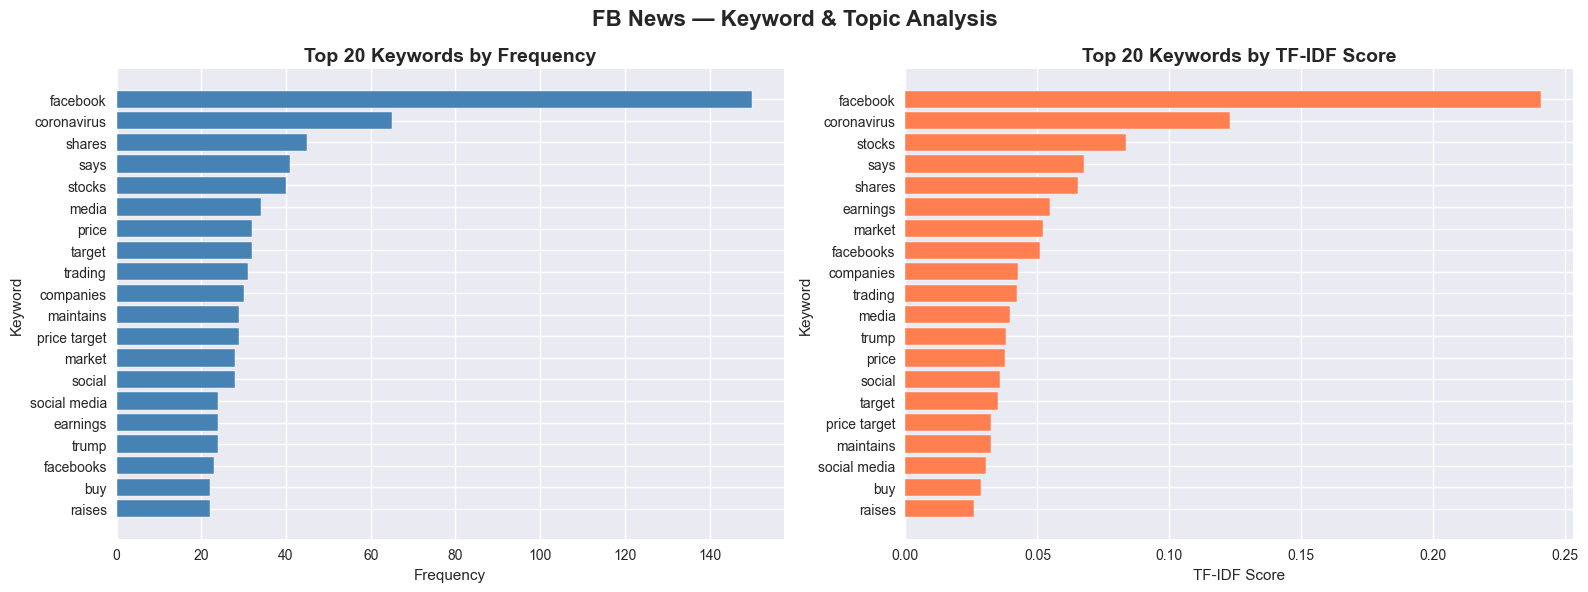

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].barh(word_freq['keyword'], word_freq['frequency'], color='steelblue', edgecolor='white')
axes[0].set_title('Top 20 Keywords by Frequency', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Frequency')
axes[0].set_ylabel('Keyword')
axes[0].invert_yaxis()

tfidf_scores = tfidf_matrix.toarray().mean(axis=0)
tfidf_df = pd.DataFrame({'keyword': tfidf_keywords, 'score': tfidf_scores})
tfidf_df = tfidf_df.sort_values('score', ascending=False)

axes[1].barh(tfidf_df['keyword'], tfidf_df['score'], color='coral', edgecolor='white')
axes[1].set_title('Top 20 Keywords by TF-IDF Score', fontsize=14, fontweight='bold')
axes[1].set_xlabel('TF-IDF Score')
axes[1].set_ylabel('Keyword')
axes[1].invert_yaxis()

plt.suptitle('FB News — Keyword & Topic Analysis', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

### 7.2 LDA Topic Modeling

Latent Dirichlet Allocation (LDA) is an unsupervised machine learning technique that discovers hidden topics in a collection of documents. We use LDA to identify the main themes discussed in FB-related headlines.

=== LDA Topic Modeling Results ===
Number of topics: 5

Topic 1: trump, media, social, market, order, executive, says, facebook, coronavirus, stats
Topic 2: facebook, says, zuckerberg, coronavirus, apple, tech, week, covid, mark, companies
Topic 3: facebook, price, target, maintains, raises, buy, earnings, amazon, lowers, outperform
Topic 4: facebook, coronavirus, shares, trading, amid, lower, several, stocks, companies, global
Topic 5: stocks, facebook, moving, communication, says, session, facebooks, shares, media, premarket


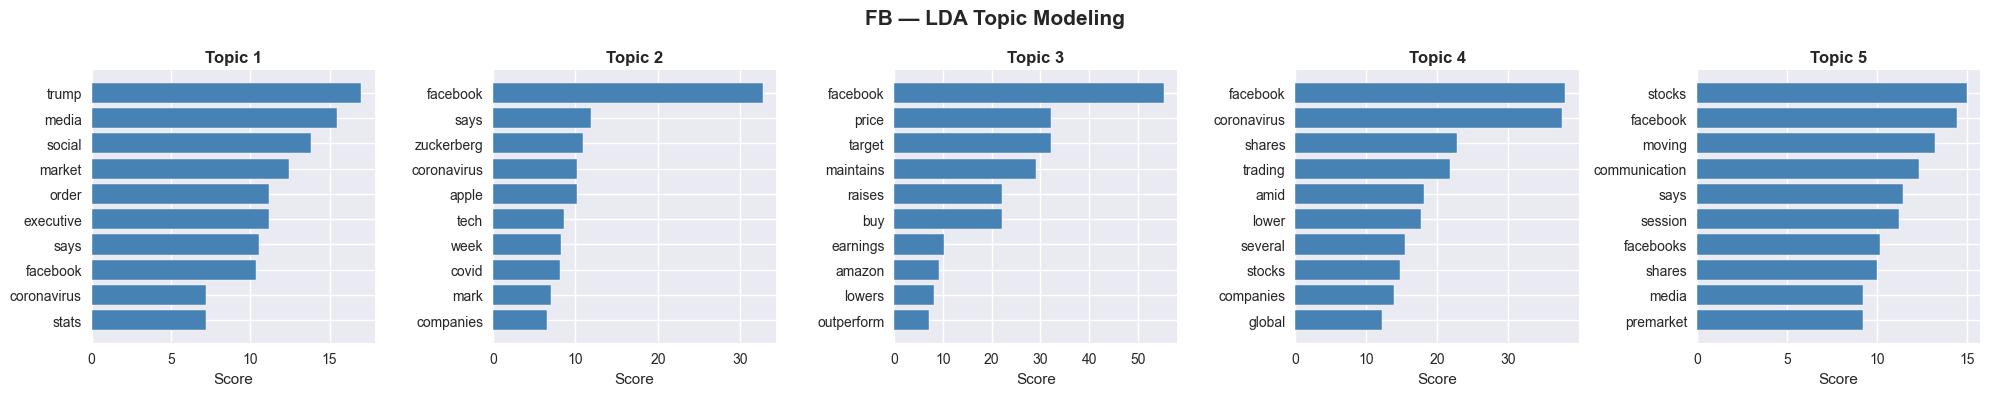

✅ LDA Topic Modeling complete!


In [15]:
# LDA Topic Modeling
lda_vectorizer = CountVectorizer(max_features=1000, ngram_range=(1,1))
lda_matrix = lda_vectorizer.fit_transform(fb_df['cleaned_headline'])

n_topics = 5
lda_model = LatentDirichletAllocation(
    n_components=n_topics,
    random_state=42,
    max_iter=10
)
lda_model.fit(lda_matrix)

feature_names = lda_vectorizer.get_feature_names_out()

print("=== LDA Topic Modeling Results ===")
print(f"Number of topics: {n_topics}\n")

topics = []
for topic_idx, topic in enumerate(lda_model.components_):
    top_words = [feature_names[i] for i in topic.argsort()[:-11:-1]]
    topics.append(top_words)
    print(f"Topic {topic_idx + 1}: {', '.join(top_words)}")

# Visualize topics
fig, axes = plt.subplots(1, n_topics, figsize=(20, 4))

for topic_idx, topic in enumerate(lda_model.components_):
    top_indices = topic.argsort()[:-11:-1]
    top_words = [feature_names[i] for i in top_indices]
    top_scores = [topic[i] for i in top_indices]

    axes[topic_idx].barh(top_words, top_scores, color='steelblue', edgecolor='white')
    axes[topic_idx].set_title(f'Topic {topic_idx + 1}', fontsize=12, fontweight='bold')
    axes[topic_idx].invert_yaxis()
    axes[topic_idx].set_xlabel('Score')

plt.suptitle('FB — LDA Topic Modeling', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()
print("✅ LDA Topic Modeling complete!")

## 8. Key Findings & Summary

A summary of the most important insights derived from the exploratory data analysis of FB-related financial news headlines.

In [16]:
print("=" * 55)
print("        FB EDA — KEY FINDINGS SUMMARY")
print("=" * 55)

print(f"""
📰 DATASET OVERVIEW
- Total FB articles analyzed : {len(fb_df)}
- Date range                   : {fb_df['date'].min().date()} to {fb_df['date'].max().date()}
- Unique publishers            : {fb_df['publisher'].nunique()}

📏 HEADLINE STATISTICS
- Average headline length      : {fb_df['headline_length'].mean():.1f} characters
- Shortest headline            : {fb_df['headline_length'].min()} characters
- Longest headline             : {fb_df['headline_length'].max()} characters

📰 PUBLISHER INSIGHTS
- Most active publisher        : {fb_df['publisher'].value_counts().index[0]}
- Articles by top publisher    : {fb_df['publisher'].value_counts().iloc[0]}

📈 NEWS VOLUME INSIGHTS
- Highest single day volume    : {daily_counts.max()} articles
- Date of highest volume       : {daily_counts.idxmax()}

🔑 TOP THEMES IDENTIFIED
- Price targets & analyst ratings
- COVID-19 / Coronavirus impact
- iPhone sales & product updates
- China operations & supply chain
- Stock trading & market movement
""")
print("=" * 55)

        FB EDA — KEY FINDINGS SUMMARY

📰 DATASET OVERVIEW
- Total FB articles analyzed : 380
- Date range                   : 2020-02-19 to 2020-06-10
- Unique publishers            : 37

📏 HEADLINE STATISTICS
- Average headline length      : 87.4 characters
- Shortest headline            : 26 characters
- Longest headline             : 290 characters

📰 PUBLISHER INSIGHTS
- Most active publisher        : Benzinga Newsdesk
- Articles by top publisher    : 111

📈 NEWS VOLUME INSIGHTS
- Highest single day volume    : 36 articles
- Date of highest volume       : 2020-04-30

🔑 TOP THEMES IDENTIFIED
- Price targets & analyst ratings
- COVID-19 / Coronavirus impact
- iPhone sales & product updates
- China operations & supply chain
- Stock trading & market movement

